# 04 — Regression: final evaluation and stacking

Reads the winning hyperparameters from notebook 03, retrains each model on the
**full** training set, and scores it once on the held-out test set.

Then builds a stacking ensemble: six base models feed their predictions to a
Ridge meta-learner that decides how much to trust each one. The ensemble is
where the headline QWK of **0.3712** comes from.

Equivalent to: `python main.py --stage eval-reg`

In [1]:
# Make the project's src/ package importable from inside notebooks/.
import os
import sys
sys.path.insert(0, os.path.abspath(".."))

import warnings

import catboost as cb
import lightgbm as lgb
import xgboost as xgb
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Lasso, Ridge
from sklearn.metrics import classification_report
from sklearn.preprocessing import StandardScaler

from src.config import EVAL_FIXED_PARAMS_REG, IMPUTER_PARAMS_REG_EVAL, PATHS
from src.data_loader import (DROP_FOR_REG_EVAL, build_imputer,
                             load_processed_split)
from src.metrics import (build_regression_stack, compare_regressor_results,
                         interpret_meta_weights, plot_confusion_matrix,
                         train_and_evaluate_regressors)
from src.models import TorchRegressor, build_model
from src.utils import load_tuned_params_by_prefix

warnings.filterwarnings("ignore")
os.makedirs(PATHS["results_dir"], exist_ok=True)

## 1. Load and preprocess

Reads `PostProcessed_reg.csv` from 02a and restores the train/test split from
its `Split` column, so the test rows here are the same ones held out back then.

Two details specific to this stage:

- **The imputer is different from the one used in tuning.** Notebook 03 ran on
  `mice`; here we use `extra_trees` (20 estimators, depth 5, 6 iterations),
  which was the top scorer in the 02a imputer study. Both are recorded in
  `src/config.py`.
- **The order is impute → scale**, whereas the fold pipeline inside tuning
  scales first. Preserved as-is, since this is what produced the published
  numbers.

Meta columns — including `is_outlier` — are dropped here, unlike in notebook 03
where `is_outlier` was left in as a feature.

In [2]:
print("Loading data (raw features)...")
X_train_raw, y_train, X_test_raw, y_test = load_processed_split(
    PATHS["reg_processed"], DROP_FOR_REG_EVAL
)

print(f"X_train_raw: {X_train_raw.shape} "
      f"(has NaNs: {X_train_raw.isnull().any().any()})")
print(f"X_test_raw:  {X_test_raw.shape} "
      f"(has NaNs: {X_test_raw.isnull().any().any()})")
print(f"Test sii distribution: {dict(y_test.value_counts())}\n")

# Fit on the training rows only, then apply the same transform to test.
print("Fitting final imputer on the FULL training set...")
imputer = build_imputer(IMPUTER_PARAMS_REG_EVAL)
X_train_imputed = imputer.fit_transform(X_train_raw)
X_test_imputed = imputer.transform(X_test_raw)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_imputed)
X_test = scaler.transform(X_test_imputed)

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")

Loading data (raw features)...
X_train_raw: (6768, 45) (has NaNs: True)
X_test_raw:  (1692, 45) (has NaNs: True)
Test sii distribution: {0: np.int64(1167), 1: np.int64(317), 2: np.int64(190), 3: np.int64(18)}

Fitting final imputer on the FULL training set...
X_train: (6768, 45)
X_test:  (1692, 45)


## 2. Rebuild the tuned models

Each model's best trial is read back from its `optuna trials/*_reg_trials.csv`.
`build_model()` casts the hyperparameters back to the right types (a CSV
round-trip turns every integer into a float) and adds a PCA step for the models
that were tuned with one.

In [3]:
# Display name -> (estimator class, filename fragment of its trials CSV).
# The fragments end in "_reg" so they only match the *regression* trials files
# (e.g. "ridge_reg_trials.csv"), never the classification ones. Without that
# suffix, "ridge" would glob both ridge_reg_trials.csv and ridge_clf_trials.csv
# and pick whichever was created most recently — which, after the classification
# stages ran, is the wrong file (and carries a pca_n_components of 46, larger
# than the 45 features in the data).
model_specs = {
    "LightGBM": (lgb.LGBMRegressor, "lgbm_reg"),
    "XGBoost": (xgb.XGBRegressor, "xgb_reg"),
    "CatBoost": (cb.CatBoostRegressor, "cb_reg"),
    "RandomForest": (RandomForestRegressor, "rf_reg"),
    "Ridge": (Ridge, "ridge_reg"),
    "Lasso": (Lasso, "lasso_reg"),
}
tuned = {name: load_tuned_params_by_prefix(prefix, PATHS["results_dir"])
         for name, (_, prefix) in model_specs.items()}

mlp_params, mlp_pca_n = load_tuned_params_by_prefix("nn_reg", PATHS["results_dir"])


def make(name):
    """Build one estimator from its tuned params plus its fixed kwargs."""
    model_class = model_specs[name][0]
    params, pca_n = tuned[name]
    return build_model(model_class, params, pca_n, EVAL_FIXED_PARAMS_REG[name])


models = {name: make(name) for name in model_specs}
if mlp_params:
    models["MLP"] = build_model(
        TorchRegressor, {**mlp_params, "device": "cpu", "verbose": False},
        mlp_pca_n,
    )

print(f"Models rebuilt: {list(models)}")

Models rebuilt: ['LightGBM', 'XGBoost', 'CatBoost', 'RandomForest', 'Ridge', 'Lasso', 'MLP']


## 3. Train and score the base models

Each model is fitted on the full training set. Because it outputs a continuous
number, its cut points into {0,1,2,3} are optimised (Nelder-Mead) on the
**training** predictions and then applied unchanged to the test predictions —
tuning them on the test set would leak the answer into the metric.

In [4]:
results = train_and_evaluate_regressors(X_train, y_train, X_test, y_test,
                                        models)

Training LightGBM...
 -> Test QWK: 0.3550
Training XGBoost...
 -> Test QWK: 0.3350
Training CatBoost...
 -> Test QWK: 0.2958
Training RandomForest...
 -> Test QWK: 0.3699
Training Ridge...
 -> Test QWK: 0.2793
Training Lasso...
 -> Test QWK: 0.2717
Training MLP...
 -> Test QWK: 0.3383


=== Base Models Test Set Performance ===
       Model  Test QWK
RandomForest  0.369863
    LightGBM  0.354959
     XGBoost  0.335013
    CatBoost  0.295779
       Ridge  0.279302
       Lasso  0.271744
         MLP  0.268844


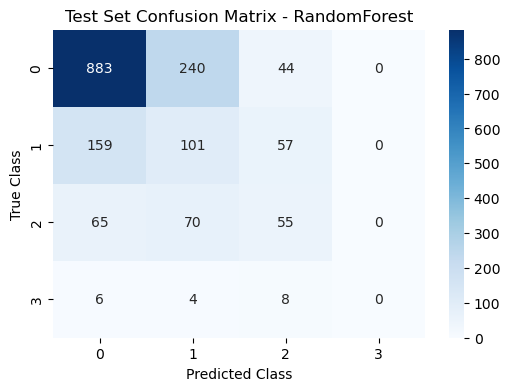

Classification Report (RandomForest):

              precision    recall  f1-score   support

           0       0.79      0.76      0.77      1167
           1       0.24      0.32      0.28       317
           2       0.34      0.29      0.31       190
           3       0.00      0.00      0.00        18

    accuracy                           0.61      1692
   macro avg       0.34      0.34      0.34      1692
weighted avg       0.63      0.61      0.62      1692



In [14]:
leaderboard = compare_regressor_results(results)

best_name = leaderboard.iloc[0]["Model"]
best_predictions = results[best_name]["Test_Class_Preds"]

plot_confusion_matrix(y_test, best_predictions,
                      f"Test Set Confusion Matrix - {best_name}")
print(f"Classification Report ({best_name}):\n")
print(classification_report(y_test, best_predictions))

## 4. Stacking ensemble

Six base models feed their predictions to a `RidgeCV` meta-learner, which is
fitted on their *out-of-fold* predictions — so it learns where each base model
is reliable rather than where it has memorised the training data.

**The MLP is excluded.** Its test QWK (~0.17) was far below the tree models
(0.35+) and including it added noise that dragged the ensemble down.

Constructing Level-1 Stacking Regressor...
Fitting Stacking Model...

=== Stacking Ensemble Performance ===
Stacking Test QWK: 0.3721


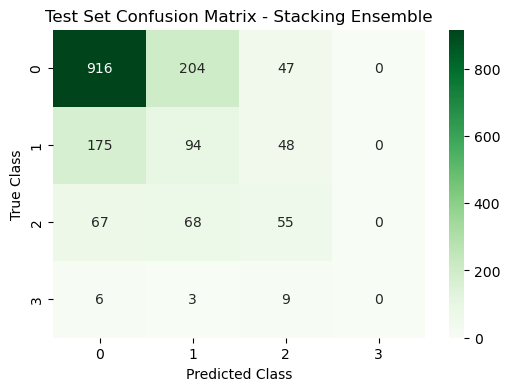

In [5]:
# Fresh instances, so the stacker fits its own copies rather than reusing the
# already-trained models above.
stack_estimators = [(name, make(name)) for name in model_specs]

print("Constructing Level-1 Stacking Regressor...")
stacking_model, stack_results = build_regression_stack(
    X_train, y_train, X_test, y_test, stack_estimators
)

## 5. What did the ensemble learn to trust?

The meta-learner's coefficients show how much weight each base model carries.
A negative coefficient is not a broken model — it means the ensemble uses that
model as a corrective counterweight to the others.

=== Meta-Model Coefficients ===
  Base Model  Meta Weight
    CatBoost     0.321453
       Ridge     0.284249
    LightGBM     0.276009
     XGBoost     0.231645
RandomForest     0.126487
       Lasso    -0.188818


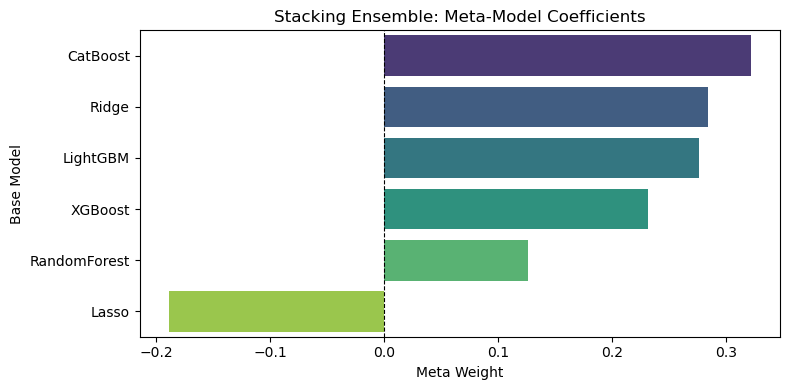

In [6]:
interpret_meta_weights(stacking_model)